In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from torch.nn.functional import cosine_similarity

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2", 
                                   output_hidden_states=True)
model.eval()

print("Ready!")
print(f"Total layers: {model.config.n_layer}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6220.57it/s]

Ready!
Total layers: 12


In [2]:
text = "The king and queen ruled the kingdom"

inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs)

# hidden_states = tuple of 13 tensors (embedding + 12 layers)
hidden_states = outputs.hidden_states

print(f"Text: {text}")
print(f"Tokens: {tokens}")
print(f"Number of hidden states: {len(hidden_states)}")
print(f"Each layer shape: {hidden_states[0].shape}")

Text: The king and queen ruled the kingdom
Tokens: ['The', 'Ġking', 'Ġand', 'Ġqueen', 'Ġruled', 'Ġthe', 'Ġkingdom']
Number of hidden states: 13
Each layer shape: torch.Size([1, 7, 768])


In [3]:

king_idx  = tokens.index('Ġking')
queen_idx = tokens.index('Ġqueen')

layer_similarities = []

for layer_idx in range(13):
    layer_embs = hidden_states[layer_idx][0]  # [7, 768]
    
    king_emb  = layer_embs[king_idx].unsqueeze(0)
    queen_emb = layer_embs[queen_idx].unsqueeze(0)
    
    sim = cosine_similarity(king_emb, queen_emb).item()
    layer_similarities.append(sim)

print("King vs Queen similarity across layers:")
print(f"\n{'Layer':<8} {'Similarity':<12}")
print("-"*20)
for i, sim in enumerate(layer_similarities):
    label = "Embedding" if i == 0 else f"Layer {i}"
    print(f"{label:<10} {sim:.4f}")

King vs Queen similarity across layers:

Layer    Similarity  
--------------------
Embedding  0.7858
Layer 1    0.8842
Layer 2    0.8627
Layer 3    0.8506
Layer 4    0.8114
Layer 5    0.7882
Layer 6    0.7962
Layer 7    0.8253
Layer 8    0.8411
Layer 9    0.8549
Layer 10   0.8582
Layer 11   0.9316
Layer 12   0.9754


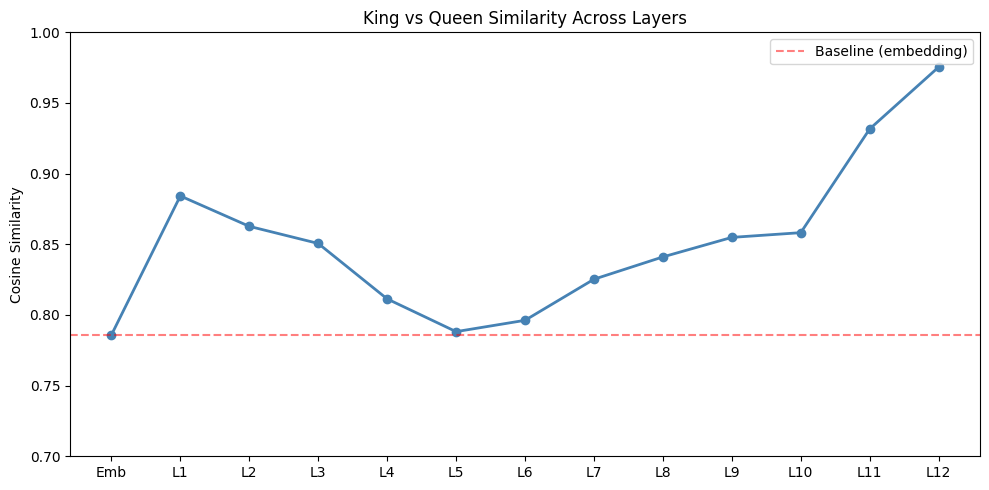

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(13), layer_similarities, 
        marker='o', color="steelblue", linewidth=2)

ax.set_xticks(range(13))
ax.set_xticklabels(
    ["Emb"] + [f"L{i}" for i in range(1, 13)])
ax.set_ylabel("Cosine Similarity")
ax.set_title("King vs Queen Similarity Across Layers")
ax.set_ylim(0.7, 1.0)
ax.axhline(y=layer_similarities[0], 
           color="red", linestyle="--", 
           alpha=0.5, label="Baseline (embedding)")
ax.legend()

plt.tight_layout()
plt.show()

In [6]:

king_across_layers = []

for layer_idx in range(13):
    layer_embs = hidden_states[layer_idx][0]
    king_emb   = layer_embs[king_idx].unsqueeze(0)
    base_emb   = hidden_states[0][0][king_idx].unsqueeze(0)
    
    sim = cosine_similarity(king_emb, base_emb).item()
    king_across_layers.append(sim)

print("King — Layer vs Embedding Layer 0:")
print(f"\n{'Layer':<10} {'Similarity':<12}")
print("-"*22)
for i, sim in enumerate(king_across_layers):
    label = "Embedding" if i == 0 else f"Layer {i}"
    print(f"{label:<10} {sim:.4f}")

King — Layer vs Embedding Layer 0:

Layer      Similarity  
----------------------
Embedding  1.0000
Layer 1    0.2527
Layer 2    0.2323
Layer 3    0.1894
Layer 4    0.1737
Layer 5    0.1435
Layer 6    0.1310
Layer 7    0.1164
Layer 8    0.0929
Layer 9    0.0757
Layer 10   0.0709
Layer 11   0.0377
Layer 12   0.0034


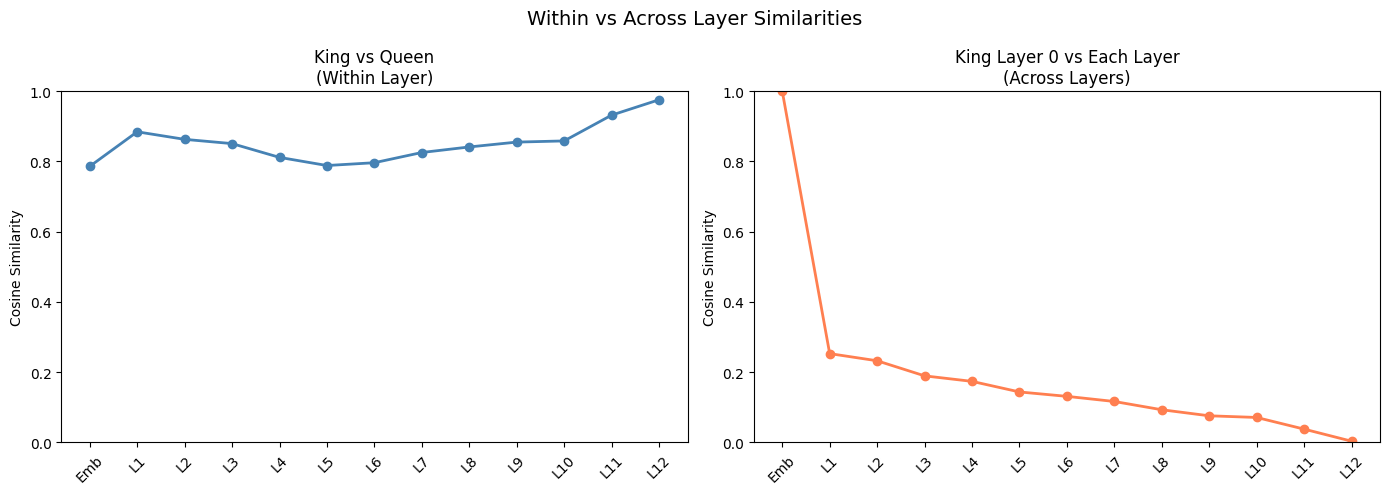

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(13)
xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]

# King vs Queen across layers
axes[0].plot(x, layer_similarities,
             marker='o', color="steelblue", linewidth=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlabels, rotation=45)
axes[0].set_ylabel("Cosine Similarity")
axes[0].set_title("King vs Queen\n(Within Layer)")
axes[0].set_ylim(0, 1.0)

# King vs itself across layers
axes[1].plot(x, king_across_layers,
             marker='o', color="coral", linewidth=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(xlabels, rotation=45)
axes[1].set_ylabel("Cosine Similarity")
axes[1].set_title("King Layer 0 vs Each Layer\n(Across Layers)")
axes[1].set_ylim(0, 1.0)

plt.suptitle("Within vs Across Layer Similarities", fontsize=14)
plt.tight_layout()
plt.show()

* **Within a layer:** In the last layer, *King* and *Queen* are highly similar (**0.97**).
* **Across layers:** *King* in Layer 0 vs Layer 12 has almost zero similarity (**0.003**).

---

**Key insights:**

* In deeper layers, related words become more similar.
* Each layer transforms the word representation by adding context.
* The final layer embeddings are completely different from the input embeddings.

---
